# Chatgpt Prompt


Build a transfer learnt model from a model trained on VGG by unfreezing some existing layers and then applying finetuning.Model Preprocessing like Gaussian Blur, Histogram Equalization. Model with Confusion Matrix and AUC 

2 Rounds of empirical tuning on the model with interpretability 

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from lime import lime_image
from skimage.segmentation import mark_boundaries
import cv2
import os
import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define dataset paths for processing

In [2]:
data_dir = "E:/Yelp-Photos/balanced_photos"
json_path = "E:/Yelp-Photos/balanced_photos.json"

In [3]:
# Load the balanced dataset metadata
df_balanced_metadata = pd.read_json(json_path, lines=True)
print("Balanced dataset size:", len(df_balanced_metadata))

Balanced dataset size: 8390


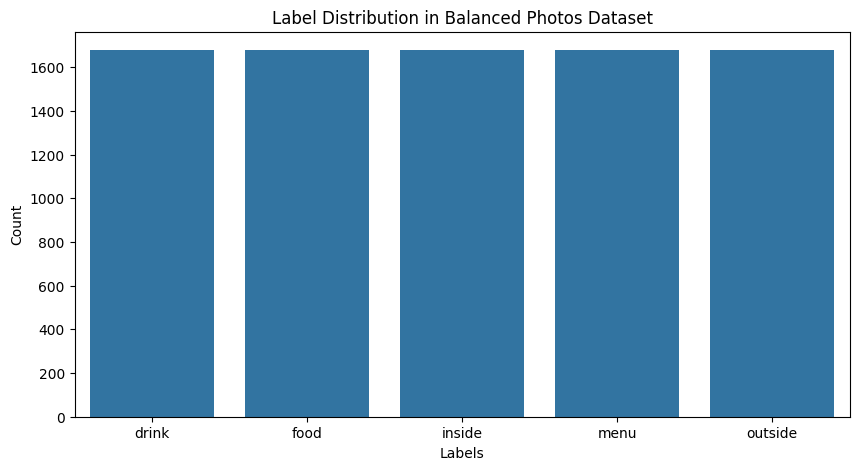

In [4]:
# Check balanced data distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(x=df_balanced_metadata['label'])
# sns.countplot(x=df_balanced_metadata['label'])
plt.title("Label Distribution in Balanced Photos Dataset")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

In [5]:
# Define constants
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [6]:
# Data Preprocessing: Apply Gaussian Blur and Histogram Equalization
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convert to grayscale
    img = cv2.GaussianBlur(img, (5,5), 0)  # Apply Gaussian Blur
    img = cv2.equalizeHist(img)  # Apply Histogram Equalization
    img = cv2.resize(img, IMG_SIZE)  # Resize to match input size
    return img

In [7]:
# Load images function
def load_images(df, data_dir, limit=20000):
    images, labels = [], []
    count, error_count = 0, 0
    for _, row in tqdm(df.iterrows(), total=len(df)):
        if count >= limit:
            break
        img_path = os.path.join(data_dir, f"{row['photo_id']}.jpg")
        if os.path.exists(img_path):
            img = preprocess_image(img_path)
            if img is not None:
                images.append(img)
                labels.append(row['label'])
                count += 1
            else:
                error_count += 1
        else:
            error_count += 1
    print(f"Total successfully loaded images: {count}")
    print(f"Total failed images: {error_count}")
    return np.array(images).reshape(-1, 128, 128, 3) / 255.0, np.array(labels)

In [26]:
# Encode labels
from sklearn.preprocessing import LabelEncoder, label_binarize
label_encoder = LabelEncoder()
df_balanced_metadata['label'] = label_encoder.fit_transform(df_balanced_metadata['label'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [27]:
# Load dataset
X, y = load_images(df_balanced_metadata, data_dir, limit=20000)

100%|████████████████████████████████████████████████████████████████████████████████████| 8390/8390 [01:02<00:00, 135.19it/s]


Total successfully loaded images: 8384
Total failed images: 6


In [60]:
# Split train and test with balanced classes
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [61]:
# Load VGG16 model without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze base model layers initially

In [62]:
# Add custom layers on top with L2 Regularization
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.6),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.6),
    Dense(len(set(y)), activation='softmax')
])

In [63]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [64]:
# Function to evaluate model and visualize LIME interpretation
def evaluate_and_interpret(model, X_val, y_val, title):
    predictions = model.predict(X_val)
    pred_labels = np.argmax(predictions, axis=1)
    
    # Compute AUC for each class
    y_bin = label_binarize(y_val, classes=np.arange(len(label_encoder.classes_)))
    auc_per_class = roc_auc_score(y_bin, predictions, multi_class='ovr', average=None)
    overall_auc = roc_auc_score(y_bin, predictions, multi_class='ovr')
    
    print(f"{title} - AUC Score: {overall_auc:.4f}")

    # Convert integer class labels to string names to avoid TypeError
    target_names = list(map(str, label_encoder.classes_))

    # Print classification report
    print(classification_report(y_val, pred_labels, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_val, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} - Confusion Matrix')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(8, 6))
    for i in range(len(target_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], predictions[:, i])
        plt.plot(fpr, tpr, label=f'Class {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} - ROC Curve')
    plt.legend()
    plt.show()

    # Print AUC for each class
    for i, class_label in enumerate(target_names):
        print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

    # LIME Interpretation - Only for misclassified samples
    misclassified_idx = np.where(y_val != pred_labels)[0]
    if len(misclassified_idx) > 0:
        idx = np.random.choice(misclassified_idx)
        explainer = lime_image.LimeImageExplainer()
        img = X_val[idx]
        explanation = explainer.explain_instance(img, model.predict, top_labels=1, hide_color=0, num_samples=1000)
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
        
        # Convert back to label names for better interpretability
        pred_class = label_encoder.inverse_transform([pred_labels[idx]])[0]
        true_class = label_encoder.inverse_transform([y_val[idx]])[0]

        plt.figure(figsize=(6, 6))
        plt.imshow(mark_boundaries(temp, mask))
        plt.axis('off')
        plt.title(f'{title} - LIME Interpretation\nTrue Class: {true_class}, Predicted Class: {pred_class}')
        plt.show()


# Train model

In [65]:
# history = model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, callbacks=[EarlyStopping(monitor='val_loss', patience=3)])
# evaluate_and_interpret(model, X_val, y_val, "")

In [66]:
# Initial Training: Unfreezing last 3 layers
for layer in base_model.layers[-3:]:  # Unfreeze last 3 layers
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_finetune = model.fit(X_train, y_train, epochs=3, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, callbacks=[EarlyStopping(monitor='val_loss', patience=2)])

Epoch 1/3
210/210 ━━━━━━━━━━━━━━━━━━━━ 974s 5s/step - accuracy: 0.3788 - loss: 4.3722 - val_accuracy: 0.7871 - val_loss: 2.6029
Epoch 2/3
210/210 ━━━━━━━━━━━━━━━━━━━━ 808s 4s/step - accuracy: 0.6723 - loss: 2.6234 - val_accuracy: 0.8312 - val_loss: 1.9735
Epoch 3/3
210/210 ━━━━━━━━━━━━━━━━━━━━ 836s 4s/step - accuracy: 0.7614 - loss: 2.0392 - val_accuracy: 0.8145 - val_loss: 1.6998


53/53 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step
Initial Training - AUC Score: 0.9647
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       336
           1       0.86      0.88      0.87       334
           2       0.66      0.86      0.74       335
           3       0.91      0.94      0.92       336
           4       0.93      0.54      0.68       336

    accuracy                           0.81      1677
   macro avg       0.83      0.81      0.81      1677
weighted avg       0.83      0.81      0.81      1677



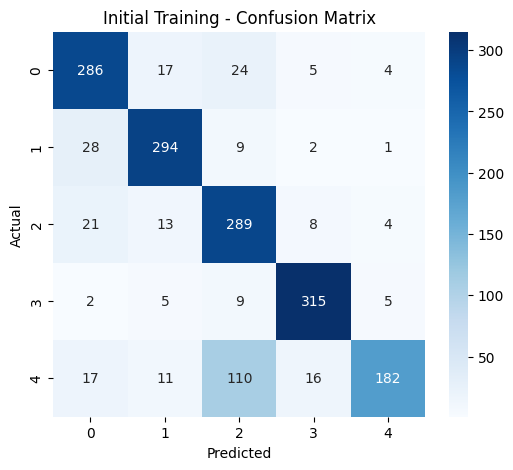

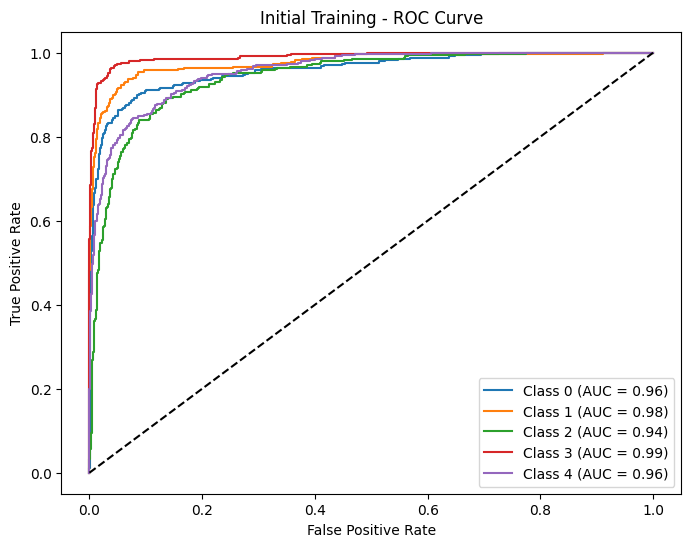

AUC for 0: 0.9590
AUC for 1: 0.9763
AUC for 2: 0.9417
AUC for 3: 0.9905
AUC for 4: 0.9560


  0%|                                                                                | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step


  1%|▋                                                                      | 10/1000 [00:00<01:36, 10.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step


...

 98%|████████████████████████████████████████████████████████████████████▌ | 980/1000 [01:51<00:02,  9.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


 99%|█████████████████████████████████████████████████████████████████████▎| 990/1000 [01:52<00:01,  9.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


100%|█████████████████████████████████████████████████████████████████████| 1000/1000 [01:54<00:00,  8.77it/s]


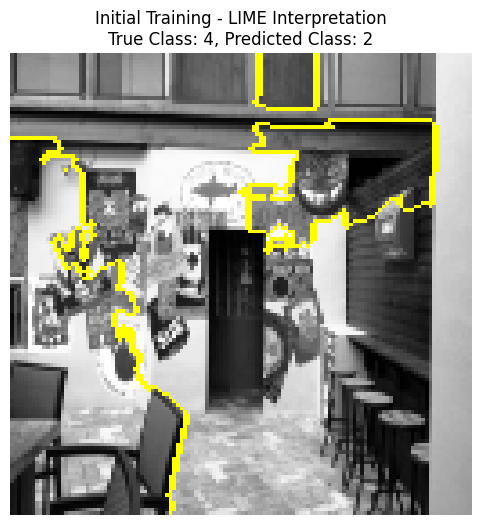

In [67]:
evaluate_and_interpret(model, X_val, y_val, "Initial Training")

# First round of empirical tuning : Unfreezing last 4 layers

In [68]:
# First round of empirical tuning
for layer in base_model.layers[-4:]:  # Unfreeze one more layer
    layer.trainable = True
model.compile(optimizer=Adam(learning_rate=0.00005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_tuning_1 = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, callbacks=[EarlyStopping(monitor='val_loss', patience=2)])


Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 823s 4s/step - accuracy: 0.8057 - loss: 1.6098 - val_accuracy: 0.8581 - val_loss: 1.3508
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 864s 4s/step - accuracy: 0.8426 - loss: 1.3333 - val_accuracy: 0.8629 - val_loss: 1.2386


53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step
1st Empirical Tuning - AUC Score: 0.9731
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       336
           1       0.88      0.89      0.88       334
           2       0.75      0.85      0.79       335
           3       0.96      0.91      0.94       336
           4       0.84      0.87      0.85       336

    accuracy                           0.86      1677
   macro avg       0.87      0.86      0.86      1677
weighted avg       0.87      0.86      0.86      1677



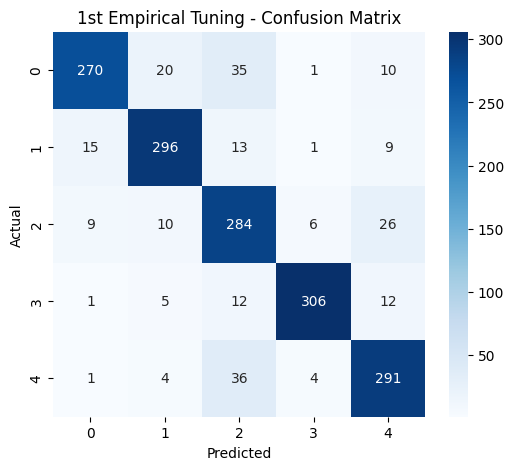

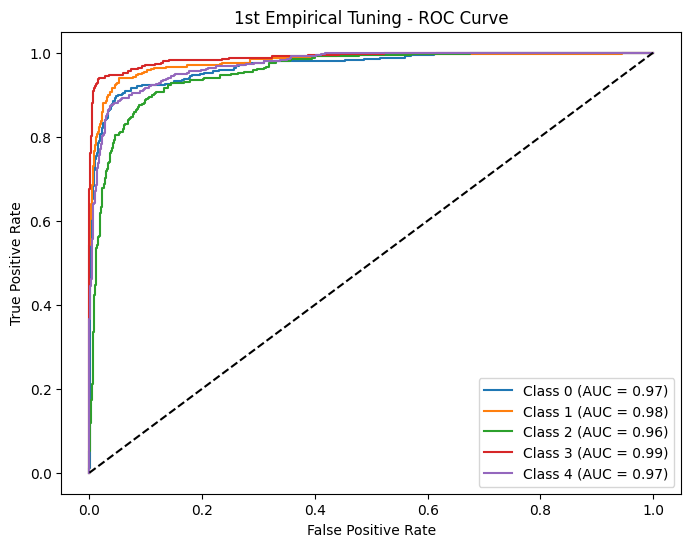

AUC for 0: 0.9693
AUC for 1: 0.9798
AUC for 2: 0.9553
AUC for 3: 0.9889
AUC for 4: 0.9723


  0%|                                                                                | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step


  1%|▋                                                                      | 10/1000 [00:01<01:42,  9.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step


...

 98%|████████████████████████████████████████████████████████████████████▌ | 980/1000 [01:42<00:02,  9.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step


 99%|█████████████████████████████████████████████████████████████████████▎| 990/1000 [01:43<00:01,  9.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


100%|█████████████████████████████████████████████████████████████████████| 1000/1000 [01:44<00:00,  9.57it/s]


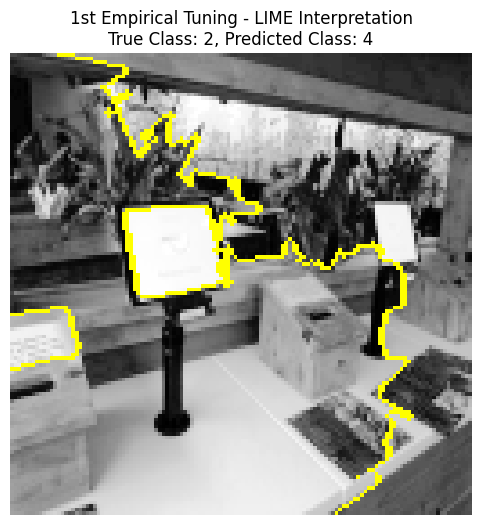

In [69]:
evaluate_and_interpret(model, X_val, y_val, "1st Empirical Tuning")

# Second round of empirical tuning

In [70]:
# Second round of empirical tuning
for layer in base_model.layers[-5:]:  # Unfreeze one additional layer
    layer.trainable = True
model.compile(optimizer=Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_tuning_2 = model.fit(X_train, y_train, epochs=2, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, callbacks=[EarlyStopping(monitor='val_loss', patience=2)])


Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 832s 4s/step - accuracy: 0.8895 - loss: 1.1448 - val_accuracy: 0.8694 - val_loss: 1.2010
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 934s 4s/step - accuracy: 0.9045 - loss: 1.0624 - val_accuracy: 0.8682 - val_loss: 1.1930


53/53 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step
2nd Empirical Tuning - AUC Score: 0.9756
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       336
           1       0.90      0.88      0.89       334
           2       0.74      0.86      0.80       335
           3       0.94      0.94      0.94       336
           4       0.90      0.82      0.85       336

    accuracy                           0.87      1677
   macro avg       0.87      0.87      0.87      1677
weighted avg       0.87      0.87      0.87      1677



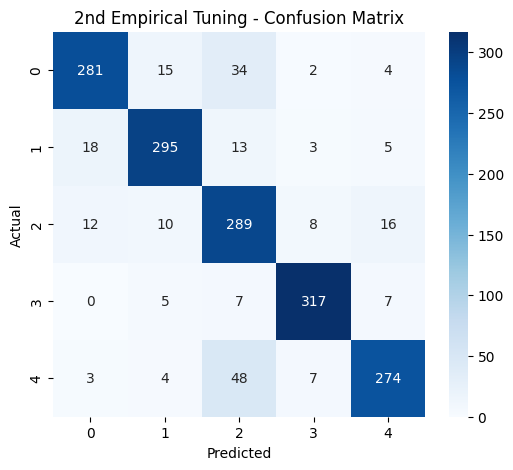

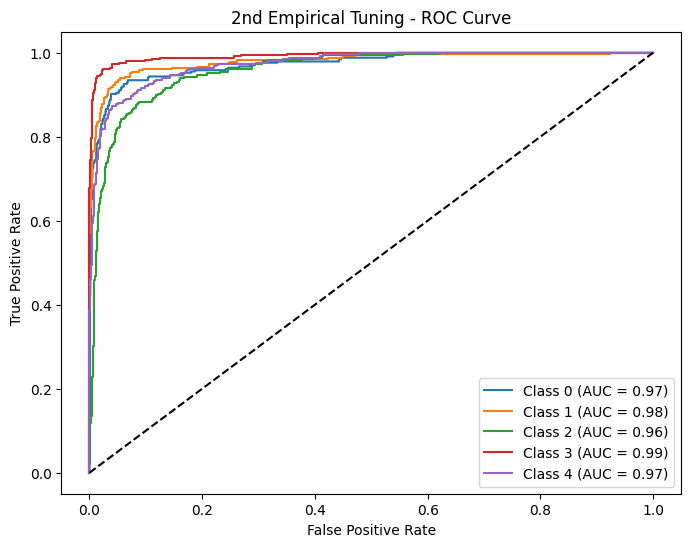

AUC for 0: 0.9735
AUC for 1: 0.9799
AUC for 2: 0.9586
AUC for 3: 0.9928
AUC for 4: 0.9730


  0%|                                                                                | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step


  1%|▋                                                                      | 10/1000 [00:01<01:41,  9.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step


...

 98%|████████████████████████████████████████████████████████████████████▌ | 980/1000 [01:46<00:02,  9.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step


 99%|█████████████████████████████████████████████████████████████████████▎| 990/1000 [01:47<00:01,  9.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step


100%|█████████████████████████████████████████████████████████████████████| 1000/1000 [01:48<00:00,  9.20it/s]


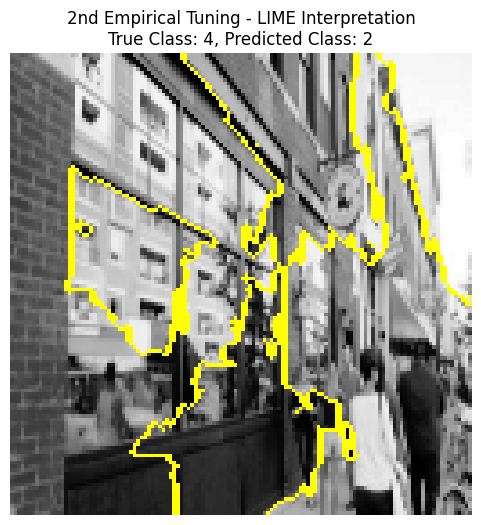

In [71]:
evaluate_and_interpret(model, X_val, y_val, "2nd Empirical Tuning")